# NYC Property Sales Analysis

##Описание задачи

Датасет о недвижимости Нью-Йорка, содержащий сведения о продажах коммерческой и жилой недвижимости. Каждый объект характеризуется набором признаков — районом расположения, площадями, налоговым классом, категорией здания и другими параметрами. Целевая переменная — SALE PRICE, то есть цена продажи объекта.

Требуется построить предсказательную модель, которая на основе характеристик объекта недвижимости сможет оценивать его стоимость. Это задача регрессии, где требуется аппроксимировать зависимость `SALE PRICE = f(признаки)`.

## Признаки

- SALE PRICE: Цена продажи в долларах (целевая переменная)
- BOROUGH: Район Нью-Йорка (1-Манхэттен, 2-Бронкс, 3-Бруклин, 4-Куинс, 5-Стейтен-Айленд)
- NEIGHBORHOOD: Микрорайон расположения объекта
- BLOCK: Номер квартала (блока) в системе кадастра Нью-Йорка
- LOT: Номер участка (лота) в пределах квартала
- ZIP CODE: Почтовый индекс расположения объекта

- BUILDING CLASS CATEGORY: Категория здания (например, "01 ONE FAMILY DWELLINGS", "02 TWO FAMILY DWELLINGS")

- LAND SQUARE FEET: Площадь земельного участка в квадратных футах
- GROSS SQUARE FEET: Общая площадь объекта в квадратных футах

- TAX CLASS AT PRESENT: Текущий налоговый класс объекта
- TAX CLASS AT TIME OF SALE: Налоговый класс на момент продажи
- BUILDING CLASS AT PRESENT: Класс здания в настоящее время
- BUILDING CLASS AT TIME OF SALE: Класс здания на момент продажи

- RESIDENTIAL UNITS: Количество жилых единиц в здании
- COMMERCIAL UNITS: Количество коммерческих единиц в здании
- TOTAL UNITS: Общее количество единиц в здании

- SALE DATE: Дата совершения сделки
- YEAR BUILT: Год постройки здания

- Unnamed: 0: Технический индекс-идентификатор

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import kagglehub

In [2]:
path = kagglehub.dataset_download("new-york-city/nyc-property-sales")
df = pd.read_csv(path + "/nyc-rolling-sales.csv")
print(f"Датасет загружен: {df.shape}")

Using Colab cache for faster access to the 'nyc-property-sales' dataset.
Датасет загружен: (84548, 22)


# Работа с выбросами

In [11]:
df_clean = df.copy()

columns_to_drop = ['Unnamed: 0', 'EASE-MENT']
df_clean = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns])

numeric_cols = ['SALE PRICE', 'LAND SQUARE FEET', 'GROSS SQUARE FEET']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean[df_clean['SALE PRICE'].notna()]
df_clean = df_clean[df_clean['GROSS SQUARE FEET'].notna()]
df_clean = df_clean[df_clean['LAND SQUARE FEET'].notna()]

if 'SALE PRICE' in df_clean.columns:
    lower_q = df_clean['SALE PRICE'].quantile(0.005)
    upper_q = df_clean['SALE PRICE'].quantile(0.995)
    df_clean = df_clean[(df_clean['SALE PRICE'] > lower_q) & (df_clean['SALE PRICE'] < upper_q)]

if 'GROSS SQUARE FEET' in df_clean.columns:
    lower_q_area = df_clean['GROSS SQUARE FEET'].quantile(0.005)
    upper_q_area = df_clean['GROSS SQUARE FEET'].quantile(0.995)
    df_clean = df_clean[(df_clean['GROSS SQUARE FEET'] > lower_q_area) | (df_clean['GROSS SQUARE FEET'].isna())]
    df_clean = df_clean[(df_clean['GROSS SQUARE FEET'] < upper_q_area) | (df_clean['GROSS SQUARE FEET'].isna())]


if 'LAND SQUARE FEET' in df_clean.columns:
    lower_q_land = df_clean['LAND SQUARE FEET'].quantile(0.005)
    upper_q_land = df_clean['LAND SQUARE FEET'].quantile(0.995)
    df_clean = df_clean[(df_clean['LAND SQUARE FEET'] > lower_q_land) | (df_clean['LAND SQUARE FEET'].isna())]
    df_clean = df_clean[(df_clean['LAND SQUARE FEET'] < upper_q_land) | (df_clean['LAND SQUARE FEET'].isna())]


if 'SALE PRICE' in df_clean.columns:
    Q1_price = df_clean['SALE PRICE'].quantile(0.25)
    Q3_price = df_clean['SALE PRICE'].quantile(0.75)
    IQR_price = Q3_price - Q1_price
    lower_bound_price = max(1000, Q1_price - 1.5 * IQR_price)
    upper_bound_price = Q3_price + 1.5 * IQR_price

    df_clean = df_clean[(df_clean['SALE PRICE'] >= lower_bound_price) & (df_clean['SALE PRICE'] <= upper_bound_price)]

if 'GROSS SQUARE FEET' in df_clean.columns:
    temp_df = df_clean[df_clean['GROSS SQUARE FEET'].notna()].copy()
    if len(temp_df) > 0:
        Q1_area = temp_df['GROSS SQUARE FEET'].quantile(0.25)
        Q3_area = temp_df['GROSS SQUARE FEET'].quantile(0.75)
        IQR_area = Q3_area - Q1_area
        lower_bound_area = max(100, Q1_area - 1.5 * IQR_area)
        upper_bound_area = Q3_area + 1.5 * IQR_area

        df_clean = df_clean[(df_clean['GROSS SQUARE FEET'] >= lower_bound_area) | (df_clean['GROSS SQUARE FEET'].isna())]
        df_clean = df_clean[(df_clean['GROSS SQUARE FEET'] <= upper_bound_area) | (df_clean['GROSS SQUARE FEET'].isna())]

if 'LAND SQUARE FEET' in df_clean.columns:
    temp_df = df_clean[df_clean['LAND SQUARE FEET'].notna()].copy()
    if len(temp_df) > 0:
        Q1_land = temp_df['LAND SQUARE FEET'].quantile(0.25)
        Q3_land = temp_df['LAND SQUARE FEET'].quantile(0.75)
        IQR_land = Q3_land - Q1_land
        lower_bound_land = max(100, Q1_land - 1.5 * IQR_land)
        upper_bound_land = Q3_land + 1.5 * IQR_land

        df_clean = df_clean[(df_clean['LAND SQUARE FEET'] >= lower_bound_land) | (df_clean['LAND SQUARE FEET'].isna())]
        df_clean = df_clean[(df_clean['LAND SQUARE FEET'] <= upper_bound_land) | (df_clean['LAND SQUARE FEET'].isna())]

categorical_columns = [
    'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
    'TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE',
    'BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE'
]

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

if 'SALE DATE' in df_clean.columns:
    df_clean['SALE DATE'] = pd.to_datetime(df_clean['SALE DATE'], errors='coerce')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23519 entries, 4199 to 84545
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         23519 non-null  category      
 1   NEIGHBORHOOD                    23519 non-null  category      
 2   BUILDING CLASS CATEGORY         23519 non-null  category      
 3   TAX CLASS AT PRESENT            23519 non-null  category      
 4   BLOCK                           23519 non-null  int64         
 5   LOT                             23519 non-null  int64         
 6   BUILDING CLASS AT PRESENT       23519 non-null  category      
 7   ADDRESS                         23519 non-null  object        
 8   APARTMENT NUMBER                23519 non-null  object        
 9   ZIP CODE                        23519 non-null  int64         
 10  RESIDENTIAL UNITS               23519 non-null  int64         
 11  COMM

In [12]:
feature_cols = ['SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET',
                'YEAR BUILT', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS']
feature_cols = [col for col in feature_cols if col in df_clean.columns]

# Заполнение пропусков медианой
for col in feature_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

X = df_clean[feature_cols].values

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Признаки: {feature_cols}")

Признаки: ['SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET', 'YEAR BUILT', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS']
<class 'pandas.core.frame.DataFrame'>
Index: 23519 entries, 4199 to 84545
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         23519 non-null  category      
 1   NEIGHBORHOOD                    23519 non-null  category      
 2   BUILDING CLASS CATEGORY         23519 non-null  category      
 3   TAX CLASS AT PRESENT            23519 non-null  category      
 4   BLOCK                           23519 non-null  int64         
 5   LOT                             23519 non-null  int64         
 6   BUILDING CLASS AT PRESENT       23519 non-null  category      
 7   ADDRESS                         23519 non-null  object        
 8   APARTMENT NUMBER                23519 non-null  object        
 9   ZIP CODE           

In [25]:
def plot_clusters(labels, X, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    unique_labels = np.unique(labels)
    n_clusters = len([c for c in unique_labels if c != -1])

    if n_clusters > 0:
        cmap = plt.get_cmap("tab20", n_clusters)
    else:
        cmap = None

    plt.figure(figsize=(10, 8))

    for cluster_id in unique_labels:
        if cluster_id == -1:
            color = "black"
            label = "Шум"
        else:
            if cmap is not None:
                color = cmap(cluster_id % n_clusters)
            else:
                color = "gray"
            label = f"Кластер {cluster_id}"

        mask = labels == cluster_id
        if mask.any():
            plt.scatter(
                X_pca[mask, 0],
                X_pca[mask, 1],
                s=20,
                color=color,
                label=label,
                alpha=0.3
            )

    plt.title(f"{title}\nPCA 1: {pca.explained_variance_ratio_[0]:.2%}, PCA 2: {pca.explained_variance_ratio_[1]:.2%}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    if len(unique_labels) > 15:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    else:
        plt.legend(loc='best')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

KMeans кластеры: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)}


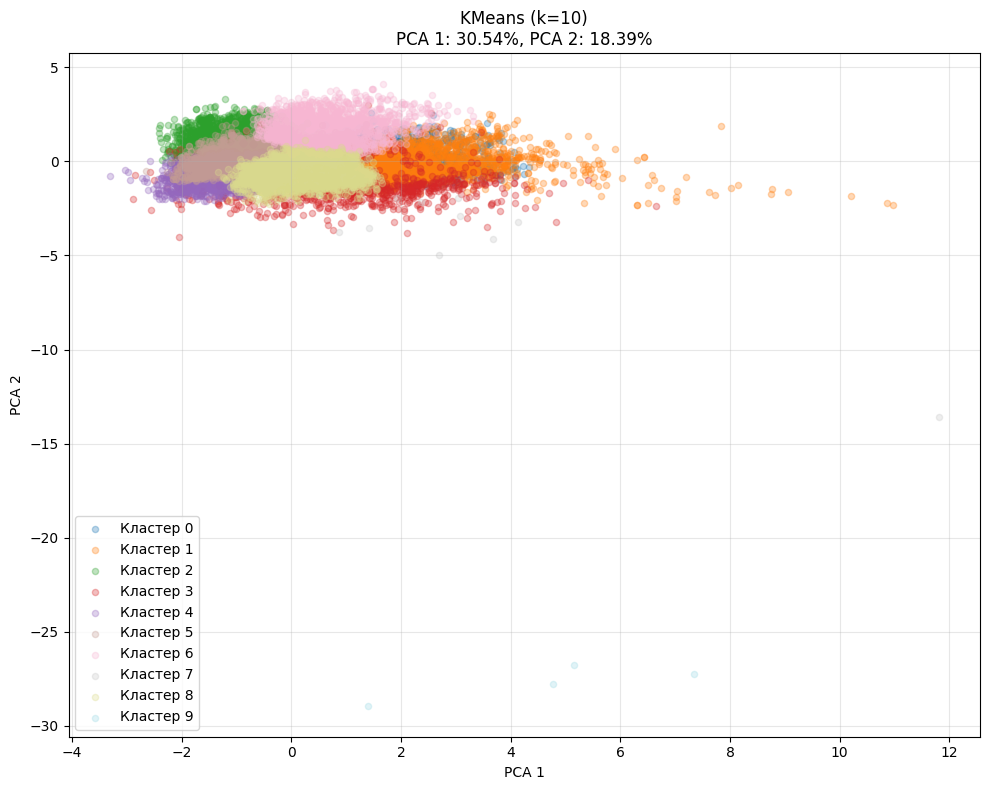

In [35]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
print(f"KMeans кластеры: {set(labels_kmeans)}")
plot_clusters(labels_kmeans, X_scaled, f"KMeans (k={k})")

DBSCAN кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(-1)}
Количество кластеров: 12
Точек шума: 4498


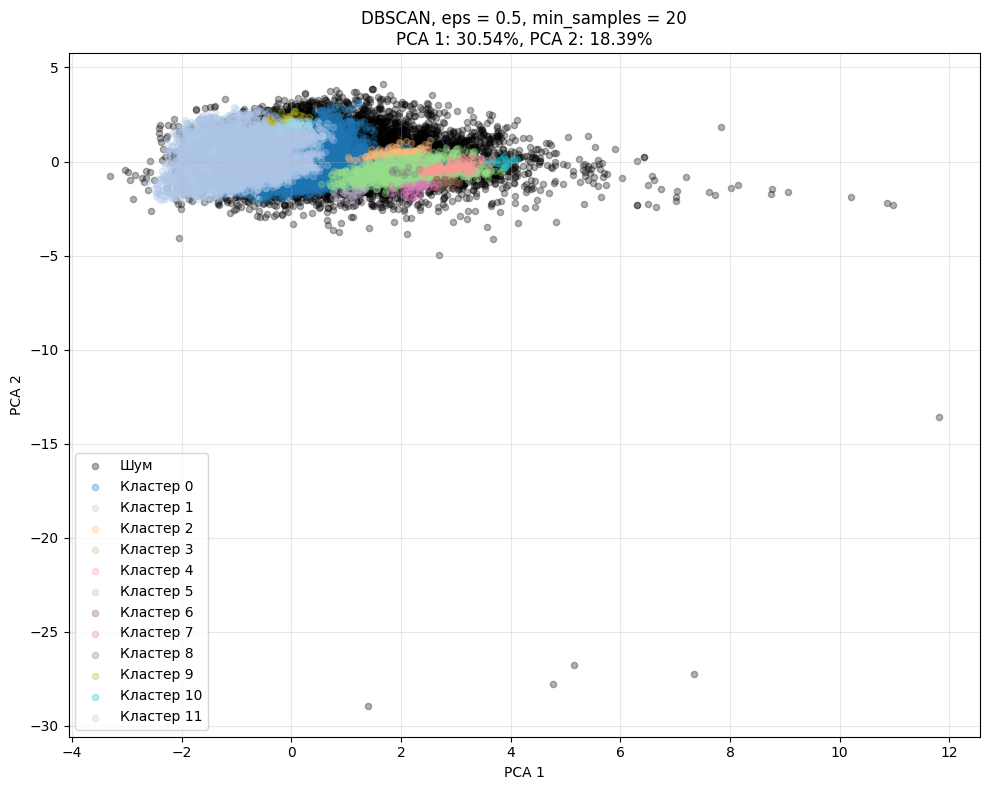

In [33]:
dbscan = DBSCAN(eps=0.5, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_scaled)
print(f"DBSCAN кластеры: {set(labels_dbscan)}")
print(f"Количество кластеров: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Точек шума: {list(labels_dbscan).count(-1)}")
plot_clusters(labels_dbscan, X_scaled, "DBSCAN, eps = 0.5, min_samples = 20")

Agglomerative кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


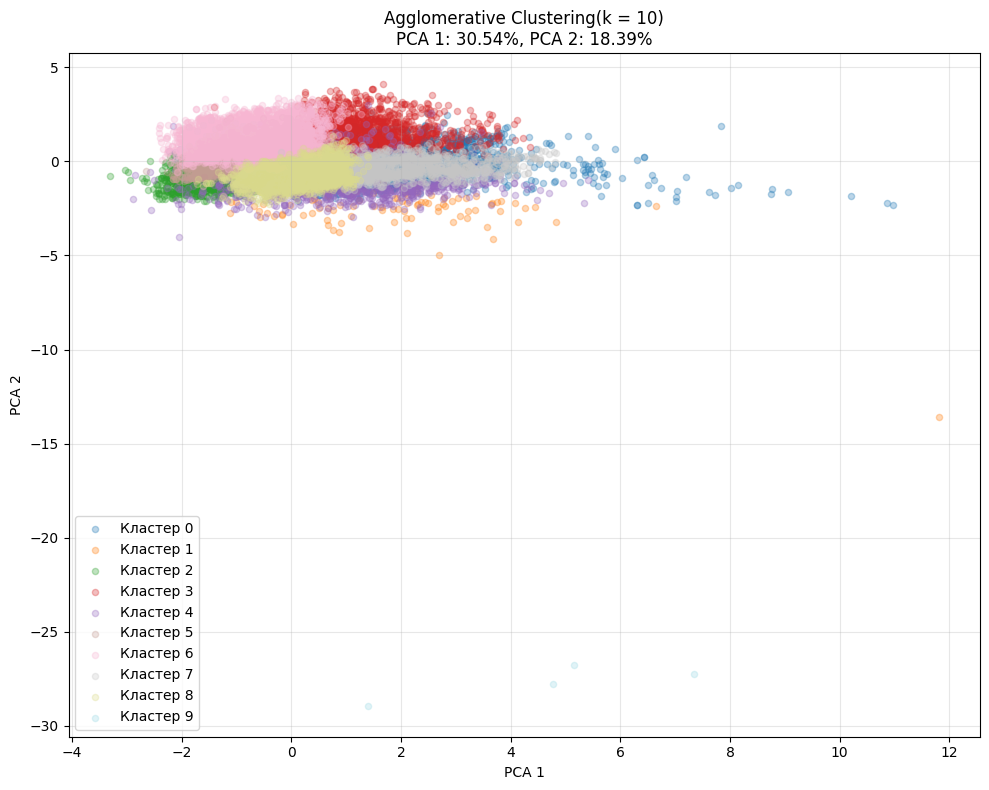

In [36]:
agg = AgglomerativeClustering(n_clusters=k)
labels_agg = agg.fit_predict(X_scaled)
print(f"Agglomerative кластеры: {set(labels_agg)}")
plot_clusters(labels_agg, X_scaled, f"Agglomerative Clustering(k={k})")

Другие гиперпараметры

KMeans кластеры: {np.int32(0), np.int32(1), np.int32(2)}


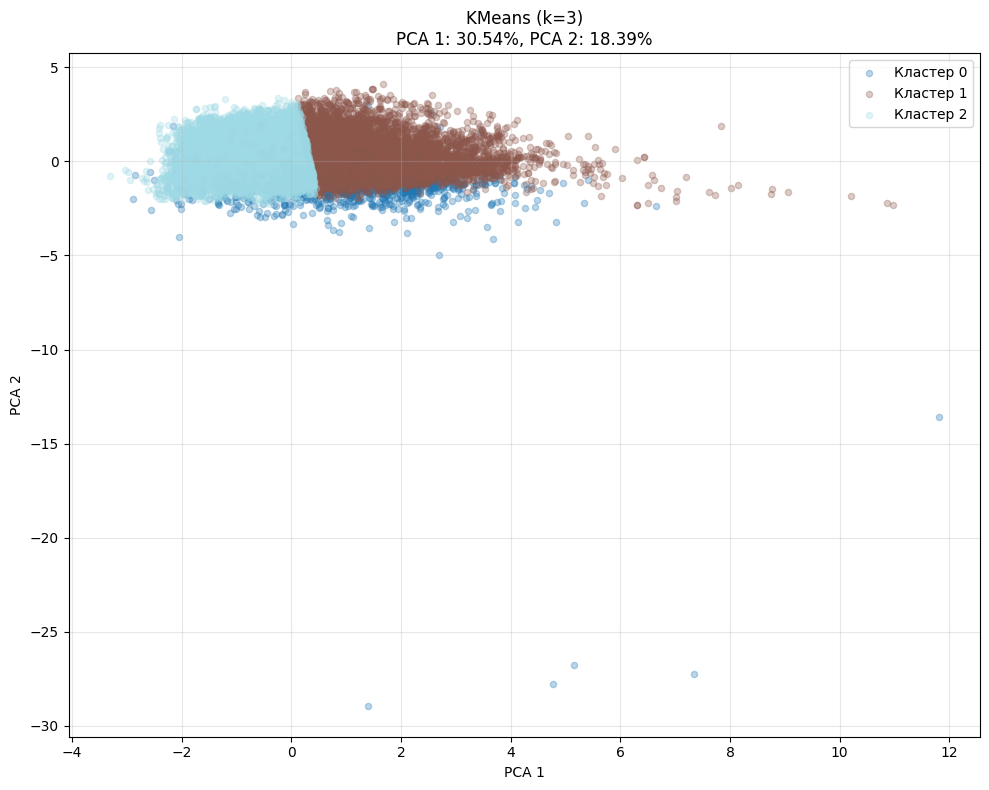

DBSCAN кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)}
Количество кластеров: 7
Точек шума: 810


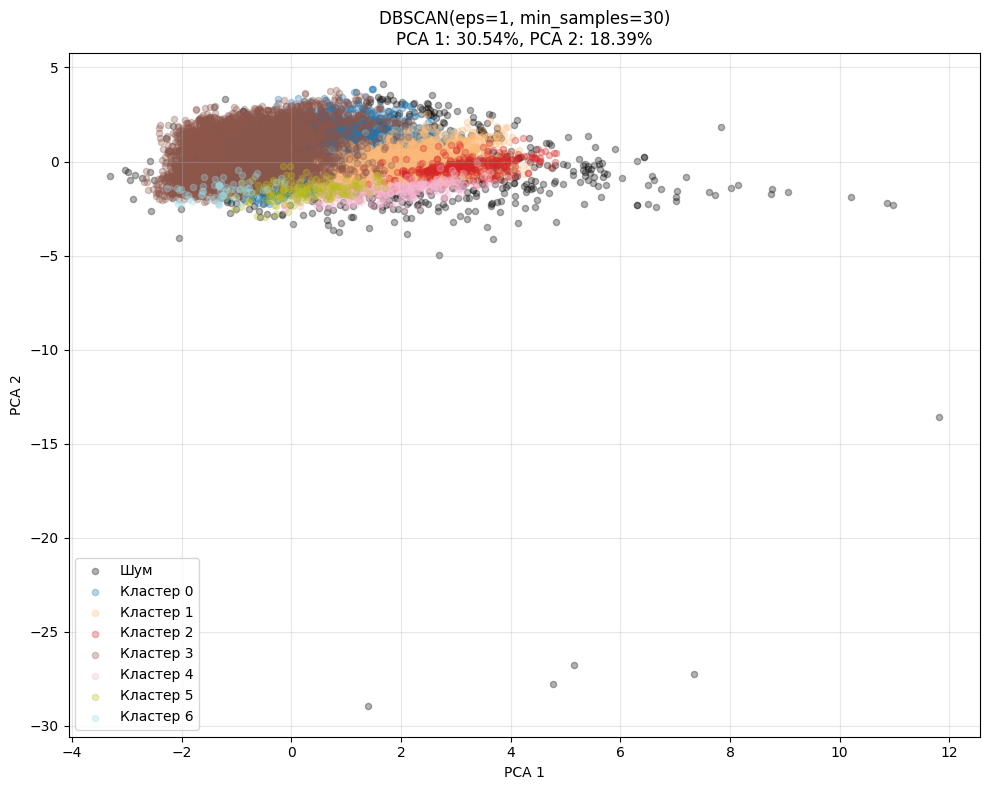

Agglomerative кластеры: {np.int64(0), np.int64(1), np.int64(2)}


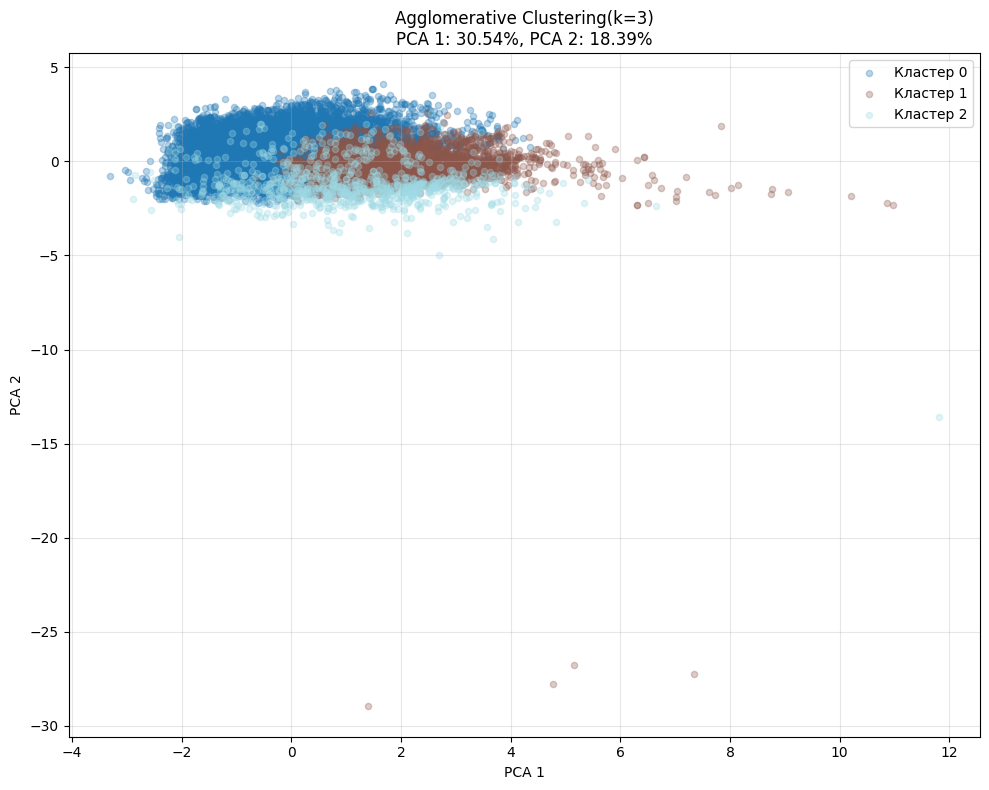

In [38]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
print(f"KMeans кластеры: {set(labels_kmeans)}")
plot_clusters(labels_kmeans, X_scaled, f"KMeans (k={k})")

dbscan = DBSCAN(eps=1, min_samples=30)
labels_dbscan = dbscan.fit_predict(X_scaled)
print(f"DBSCAN кластеры: {set(labels_dbscan)}")
print(f"Количество кластеров: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Точек шума: {list(labels_dbscan).count(-1)}")
plot_clusters(labels_dbscan, X_scaled, "DBSCAN(eps=1, min_samples=30)")

agg = AgglomerativeClustering(n_clusters=k)
labels_agg = agg.fit_predict(X_scaled)
print(f"Agglomerative кластеры: {set(labels_agg)}")
plot_clusters(labels_agg, X_scaled, f"Agglomerative Clustering(k={k})")

KMeans кластеры: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5)}


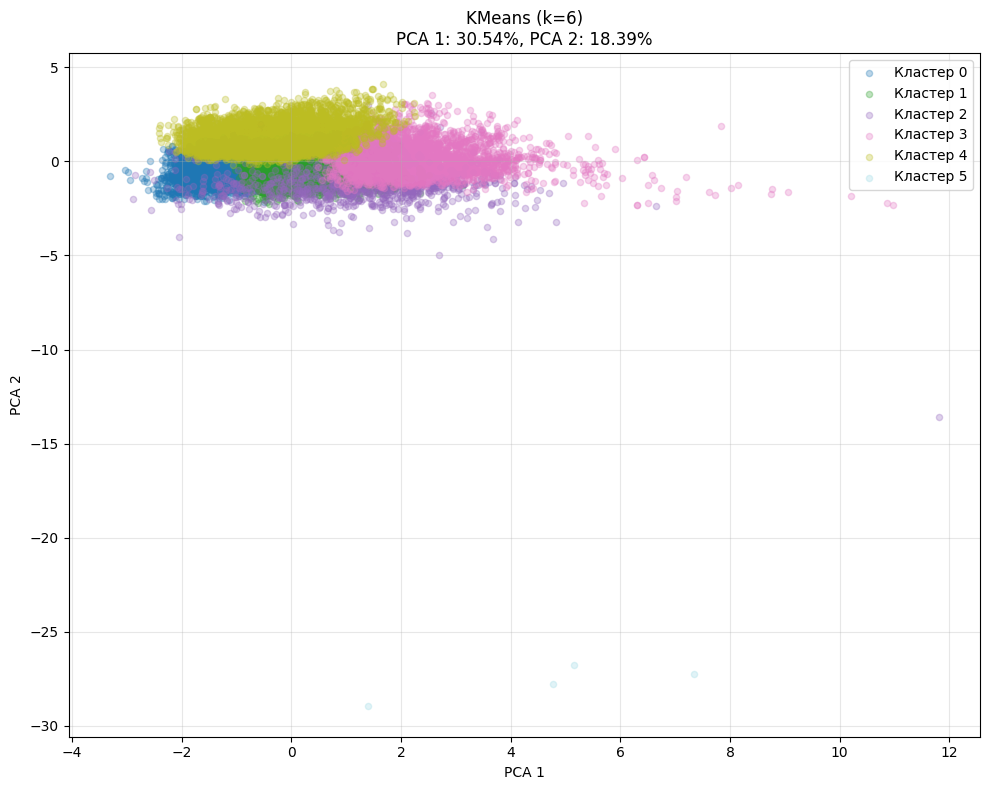

DBSCAN кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}
Количество кластеров: 4
Точек шума: 53


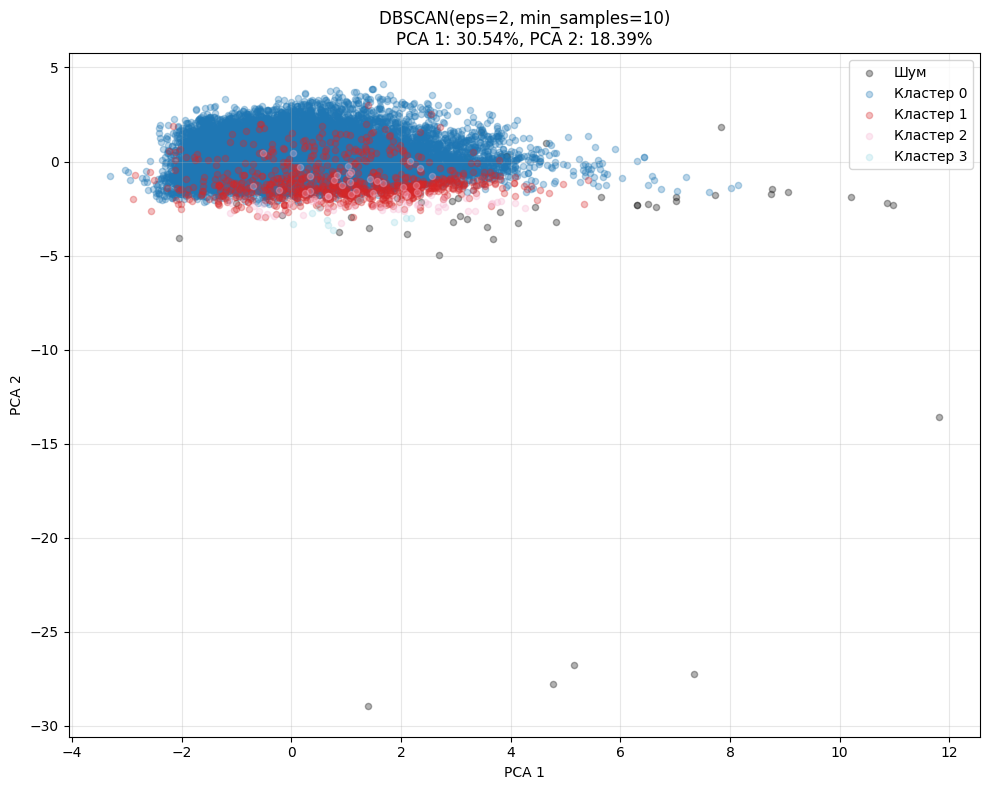

Agglomerative кластеры: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}


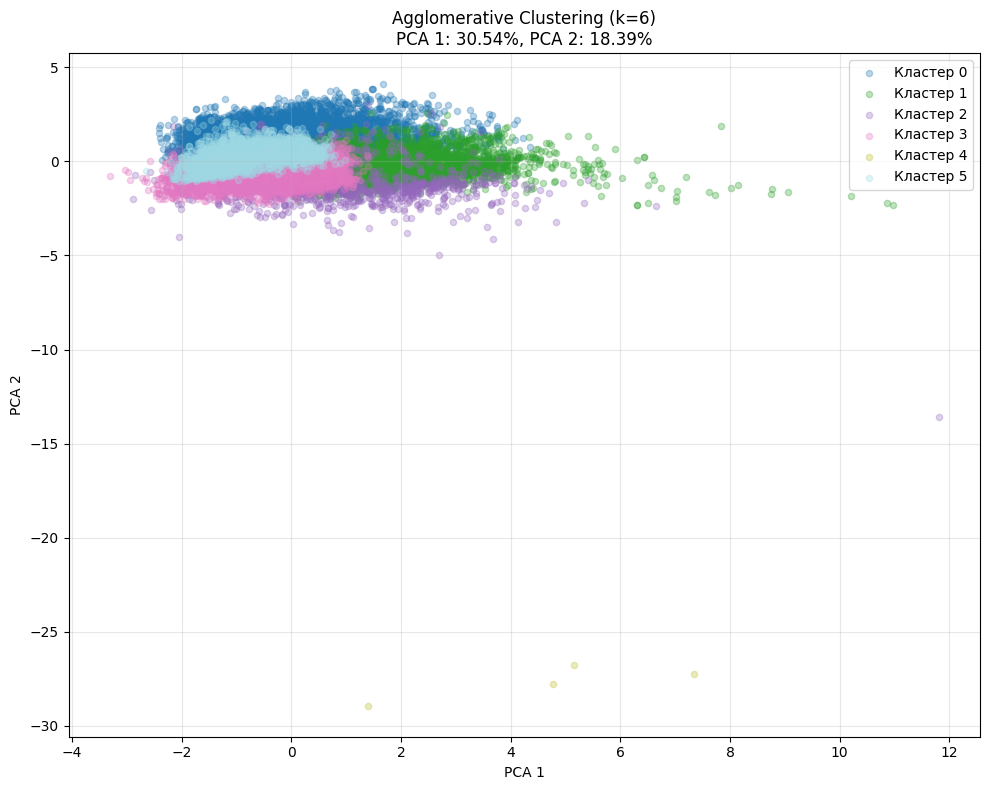

In [40]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
print(f"KMeans кластеры: {set(labels_kmeans)}")
plot_clusters(labels_kmeans, X_scaled, f"KMeans (k={k})")

dbscan = DBSCAN(eps=2, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)
print(f"DBSCAN кластеры: {set(labels_dbscan)}")
print(f"Количество кластеров: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")
print(f"Точек шума: {list(labels_dbscan).count(-1)}")
plot_clusters(labels_dbscan, X_scaled, "DBSCAN(eps=2, min_samples=10)")

agg = AgglomerativeClustering(n_clusters=k)
labels_agg = agg.fit_predict(X_scaled)
print(f"Agglomerative кластеры: {set(labels_agg)}")
plot_clusters(labels_agg, X_scaled, f"Agglomerative Clustering (k={k})")

# Вывод

Анализируя визуализации результатов трех алгоритмов кластеризации, можно наблюдать несколько важных закономерностей. Прежде всего, PCA-проекция сохраняет лишь около 49% дисперсии исходных данных (30.54% + 18.39%), что указывает на существенную потерю информации при сжатии до двух измерений. Это важный контекст для интерпретации: кластеры могут выглядеть перекрывающимися на визуализации, но быть лучше разделенными в исходном многомерном пространстве.

Для K-Means алгоритма прослеживается четкая зависимость качества кластеризации от параметра K. При K=3 формируются крупные, компактные и визуально хорошо разделенные группы. Такая кластеризация, вероятно, соответствует крупным рыночным сегментам. Увеличение K до 6 приводит к более детальной сегментации, появляются субкластеры внутри основных групп. Однако уже при K=10 наблюдается явное переобучение: алгоритм начинает выделять искусственные, неустойчивые кластеры, часто представляющие собой просто небольшие сгустки точек, что не несет практической ценности для анализа рынка.

DBSCAN демонстрирует принципиально иной подход к формированию кластеров, основанный на лоальной плотности точек. Результаты существенно варьируются в зависимости от параметров `eps` (радиус окрестности) и `min_samples`. При высоком значении `eps=2` алгоритм объединяет большие области, но выделяет значительное количество точек как шум (черные точки). При уменьшении `eps` до 0.5 картина дробится на множество мелких кластеров с очень высоким процентом шума (конфигурация с 12 кластерами). Наиболее сбалансированный результат виден при `eps=1` и `min_samples=30` — 7 кластеров, но проблема шума остается. Это указывает на то, что распределение объектов недвижимости в признаковом пространстве не образует четких областей с равномерно высокой плотностью, что является ключевым предположением для эффективной работы DBSCAN.

Agglomerative Clustering (иерархическая кластеризация) показывает результаты, визуально схожие с K-Means, что логично, так как оба алгоритма стремятся минимизировать внутрикластерную дисперсию. При одинаковом K кластеры выглядят сопоставимо по размеру и форме. Как и в случае с K-Means, оптимальное число кластеров для этой задачи лежит в диапазоне от 3 до 6.

Важно отметить, что все алгоритмы работают с данными, прошедшими агрессивную предобработку. Это могло "сгладить" распределение, устранив редкие, но потенциально важные объекты (например, экстремально дорогую недвижимость), что повлияло на итоговую структуру кластеров, особенно на работу DBSCAN, чувствительного к аномалиям.

## Итог

1.  **Оптимальный алгоритм для задачи** — **K-Means**. Он демонстрирует наиболее стабильные, воспроизводимые и легко интерпретируемые результаты. Кластеры получаются компактными и хорошо разделенными.
2.  **Рекомендуемое число кластеров (K)** — **от 3 до 6**. При K=3 выделяются основные, глобальные сегменты рынка. K=6 позволяет провести более детальную сегментацию внутри этих крупных групп. Значения K ≥ 10 приводят к избыточному дроблению и переобучению.
3.  **Agglomerative Clustering** является **рабочей альтернативой** K-Means, давая схожие результаты. Его ключевое преимущество — иерархическая структура, позволяющая гибко выбирать уровень детализации кластеризации (с помощью дендрограммы).
4.  **DBSCAN показал низкую эффективность** для данного датасета. Высокий процент точек, классифицируемых как шум (до 50% и более при некоторых параметрах), и сильная зависимость результата от тонкой настройки параметров `eps` и `min_samples` делают его непрактичным для анализа рынка недвижимости.